# Plot the effect of the plate-position correction on the feature space

Draw the figures of `2.effect_on_feature_space.ipynb` with ggplot2.
The correction subtracts a plate-position effect (the tilt) from every cell.
The figures show how large the tilt is for each kind of feature, and what the correction does to the wells.

**Inputs** (in `results/`, from `2.effect_on_feature_space.ipynb`): `tilt_size_by_feature.csv`, `well_pca_scores.csv`, and `pc_variance_explained_by_row.csv`.

**Outputs** (in `figures/effect/`)

- `tilt_size_by_feature_family.png`
- `well_pca_before_after_by_row.png`, with a panel for the displacement of the wells
- `plate_layout_top_row_pc_before_after.png`

## Load the libraries

In [1]:
library(ggplot2)
library(dplyr)
library(readr)
library(cowplot)


Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Set paths and define the helper functions


In [2]:
figure_dir <- file.path("figures", "effect")
dir.create(figure_dir, recursive = TRUE, showWarnings = FALSE)

# Measurement types that identify or locate objects, which are not morphology measurements
non_morphology <- c("Parent", "Number", "Location", "Children")

read_result <- function(name) {
    readr::read_csv(file.path("results", name), show_col_types = FALSE)
}

wrap_text <- function(text, width) {
    paste(strwrap(text, width = width), collapse = "\n")
}

# A line of text for the top or bottom of a figure that cowplot builds from several plots
text_row <- function(text, size = 10.5) {
    cowplot::ggdraw() + cowplot::draw_label(text, x = 0.01, hjust = 0, size = size)
}

family_panel <- function(tilt_sizes, column, title) {
    data <- tilt_sizes |>
        group_by(group = .data[[column]]) |>
        mutate(label = paste0(group, " (", n(), ")")) |>
        ungroup()
    data$label <- reorder(data$label, data$tilt_rms, FUN = median)
    (
        ggplot(data, aes(x = tilt_rms, y = label))
        + geom_boxplot(fill = "lightsteelblue", outlier.size = 0.6, outlier.alpha = 0.5)
        + labs(title = title, x = "Tilt size (RMS, in single-cell standard deviations)", y = NULL)
        + theme_bw(base_size = 13)
        + theme(plot.title.position = "panel")
    )
}

axis_label <- function(variance_by_row, component) {
    share <- variance_by_row$variance_explained[variance_by_row$component == component]
    sprintf("%s (%.0f%% of variance)", component, 100 * share)
}

row_share <- function(variance_by_row, component, column) {
    100 * variance_by_row[[column]][variance_by_row$component == component]
}

view_limits <- function(values) {
    q <- quantile(values, c(0.01, 0.99))
    pad <- 0.08 * diff(q)
    c(q[1] - pad, q[2] + pad)
}

## Size of the tilt by feature family

The tilt size of a feature is the root mean square (RMS) of its tilt over the 60 plate positions (6 rows by 10 columns), in standard deviations of a single cell.
A larger tilt size means that plate position shifts the feature more, so the feature needs the correction more.
We leave out the measurement types `Parent`, `Number`, `Location`, and `Children`, because they identify or locate objects and are not morphology measurements.

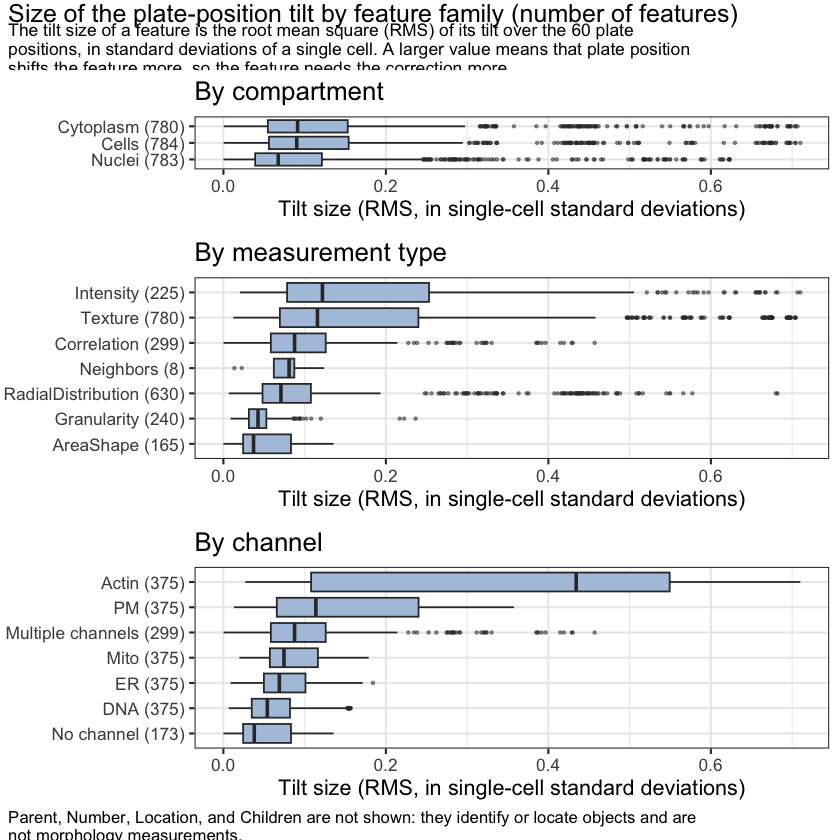

In [3]:
tilt_sizes <- read_result("tilt_size_by_feature.csv") |>
    filter(!measurement %in% non_morphology)

families <- c("compartment", "measurement", "channel")
titles <- c("By compartment", "By measurement type", "By channel")
n_groups <- sapply(families, function(column) n_distinct(tilt_sizes[[column]]))
panels <- Map(function(column, title) family_panel(tilt_sizes, column, title), families, titles)
figure <- cowplot::plot_grid(
    text_row("Size of the plate-position tilt by feature family (number of features)", size = 15),
    text_row(wrap_text(
        paste(
            "The tilt size of a feature is the root mean square (RMS) of its tilt over the 60 plate positions,",
            "in standard deviations of a single cell. A larger value means that plate position shifts the feature",
            "more, so the feature needs the correction more."
        ), 95
    )),
    cowplot::plot_grid(plotlist = panels, ncol = 1, rel_heights = n_groups + 2, align = "v", axis = "lr"),
    text_row(wrap_text(
        "Parent, Number, Location, and Children are not shown: they identify or locate objects and are not morphology measurements.",
        95
    ), size = 10),
    ncol = 1, rel_heights = c(0.035, 0.06, 1, 0.04)
)
print(figure)
ggsave(
    file.path(figure_dir, "tilt_size_by_feature_family.png"), figure,
    dpi = 300, width = 8, height = 0.32 * sum(n_groups) + 6, bg = "white"
)

## Wells in the row-dependent principal components

A principal component (PC) is a direction in which the well profiles vary, and the score of a well on a PC is its position along that direction.
We fit the principal components on the uncorrected wells and project both the uncorrected and the corrected wells into them.
The largest components depend little on the plate row (PC1 is the largest and plate row explains about 1% of it), so we draw the two components that plate row explains most before the correction.
These are PC2 and PC3, and the figure states the share of each that plate row explains.
A few extreme wells stretch the axes, so the view covers the central 98% of the wells.
The wells with a black outline are the DMSO controls.
The last panel shows the displacement of the wells from before to after the correction, in a zoomed view: the bold arrows are the mean displacement of each plate row, and the thin arrows are a sample of wells.

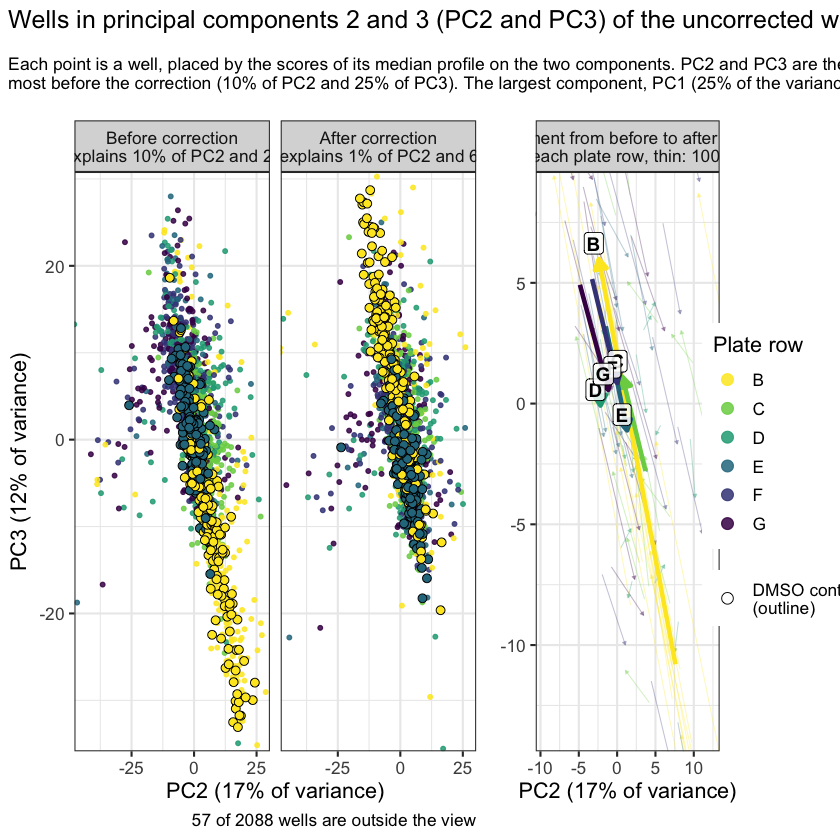

In [4]:
row_letters <- c("B", "C", "D", "E", "F", "G")
row_colors <- setNames(scales::viridis_pal(direction = -1)(6), row_letters)

scores <- read_result("well_pca_scores.csv") |>
    mutate(
        version = factor(version, levels = c("Before correction", "After correction")),
        well_row = factor(well_row, levels = row_letters)
    )
variance_by_row <- read_result("pc_variance_explained_by_row.csv") |>
    mutate(number = as.integer(sub("PC", "", component)))

row_components <- variance_by_row |>
    slice_max(row_explains_before, n = 2) |>
    arrange(number)
pc_x <- row_components$component[1]
pc_y <- row_components$component[2]

panel_titles <- c(
    "Before correction" = sprintf(
        "Before correction\nplate row explains %.0f%% of %s and %.0f%% of %s",
        row_share(variance_by_row, pc_x, "row_explains_before"), pc_x, row_share(variance_by_row, pc_y, "row_explains_before"), pc_y
    ),
    "After correction" = sprintf(
        "After correction\nplate row explains %.0f%% of %s and %.0f%% of %s",
        row_share(variance_by_row, pc_x, "row_explains_after"), pc_x, row_share(variance_by_row, pc_y, "row_explains_after"), pc_y
    )
)
n_examples <- 100
displacement_title <- sprintf(
    "Displacement from before to after (zoomed)\nbold: mean of each plate row, thin: %d example wells", n_examples
)
panel_levels <- c(panel_titles, displacement_title)
scores <- scores |> mutate(panel = factor(panel_titles[as.character(version)], levels = panel_levels))

before <- scores |>
    filter(version == "Before correction") |>
    select(plate, well, well_row, bx = all_of(pc_x), by = all_of(pc_y))
after <- scores |>
    filter(version == "After correction") |>
    select(plate, well, ax = all_of(pc_x), ay = all_of(pc_y))
displacement <- inner_join(before, after, by = c("plate", "well")) |>
    mutate(panel = factor(displacement_title, levels = panel_levels))
row_means <- displacement |>
    group_by(panel, well_row) |>
    summarize(across(c(bx, by, ax, ay), mean), .groups = "drop")
set.seed(0)
examples <- slice_sample(displacement, n = n_examples)

x_limits <- view_limits(scores[[pc_x]])
y_limits <- view_limits(scores[[pc_y]])
n_outside <- scores |>
    group_by(plate, well) |>
    summarize(
        outside = any(.data[[pc_x]] < x_limits[1] | .data[[pc_x]] > x_limits[2] |
            .data[[pc_y]] < y_limits[1] | .data[[pc_y]] > y_limits[2]),
        .groups = "drop"
    )

# the displacement panel has its own view, zoomed on the mean arrows
x_range <- range(c(row_means$bx, row_means$ax))
y_range <- range(c(row_means$by, row_means$ay))
half <- 0.65 * max(diff(x_range), diff(y_range))
x_center <- mean(x_range)
y_center <- mean(y_range)

control_label <- "DMSO control\n(outline)"
wells_plot <- (
    ggplot(scores, aes(x = .data[[pc_x]], y = .data[[pc_y]]))
    + geom_point(data = filter(scores, !is_control), aes(color = well_row), size = 1, alpha = 0.85)
    + geom_point(
        data = filter(scores, is_control), aes(fill = well_row, shape = control_label),
        color = "black", size = 2.2, stroke = 0.4
    )
    + facet_wrap(vars(panel))
    + scale_color_manual(values = row_colors, name = "Plate row")
    + scale_fill_manual(values = row_colors, guide = "none")
    + scale_shape_manual(values = setNames(21, control_label), name = NULL)
    + guides(
        color = guide_legend(order = 1, override.aes = list(size = 3)),
        shape = guide_legend(order = 2, override.aes = list(fill = "white", color = "black", size = 3))
    )
    + coord_cartesian(xlim = x_limits, ylim = y_limits)
    + labs(
        x = axis_label(variance_by_row, pc_x), y = axis_label(variance_by_row, pc_y),
        caption = sprintf("%d of %d wells are outside the view", sum(n_outside$outside), nrow(n_outside))
    )
    + theme_bw(base_size = 13)
    + theme(legend.position = "right")
)
displacement_plot <- (
    ggplot()
    + geom_segment(
        data = examples, aes(x = bx, y = by, xend = ax, yend = ay, color = well_row),
        arrow = arrow(length = unit(0.08, "cm"), type = "closed"), alpha = 0.3, linewidth = 0.3
    )
    + geom_segment(
        data = row_means, aes(x = bx, y = by, xend = ax, yend = ay, color = well_row),
        arrow = arrow(length = unit(0.25, "cm"), type = "closed"), linewidth = 1.3
    )
    + geom_label(
        data = row_means, aes(x = ax, y = ay, label = well_row),
        nudge_x = -0.06 * half, nudge_y = 0.06 * half, fontface = "bold", size = 4,
        label.padding = unit(0.12, "lines"), alpha = 0.85
    )
    + facet_wrap(vars(panel))
    + scale_color_manual(values = row_colors, name = "Plate row")
    + coord_cartesian(xlim = x_center + c(-half, half), ylim = y_center + c(-half, half))
    + labs(x = axis_label(variance_by_row, pc_x), y = NULL)
    + theme_bw(base_size = 13)
    + theme(legend.position = "none")
)

legend <- cowplot::get_legend(wells_plot)
largest <- variance_by_row |> slice_max(variance_explained, n = 1)
figure <- cowplot::plot_grid(
    text_row(
        sprintf(
            "Wells in principal components %d and %d (%s and %s) of the uncorrected wells, before and after the correction",
            row_components$number[1], row_components$number[2], pc_x, pc_y
        ),
        size = 15
    ),
    text_row(wrap_text(
        sprintf(
            paste(
                "Each point is a well, placed by the scores of its median profile on the two components.",
                "%s and %s are the two components that plate row explains most before the correction (%.0f%% of %s and %.0f%% of %s).",
                "The largest component, %s (%.0f%% of the variance), depends little on plate row (%.0f%%)."
            ),
            pc_x, pc_y, row_share(variance_by_row, pc_x, "row_explains_before"), pc_x,
            row_share(variance_by_row, pc_y, "row_explains_before"), pc_y,
            largest$component, 100 * largest$variance_explained,
            100 * largest$row_explains_before
        ), 150
    )),
    cowplot::plot_grid(
        wells_plot + theme(legend.position = "none"), displacement_plot, legend,
        nrow = 1, rel_widths = c(2, 1, 0.45), align = "h", axis = "tb"
    ),
    ncol = 1, rel_heights = c(0.05, 0.1, 1)
) + theme(plot.background = element_rect(fill = "white", color = NA))
print(figure)
ggsave(file.path(figure_dir, "well_pca_before_after_by_row.png"), figure, dpi = 300, width = 20, height = 7.5, bg = "white")

## The most row-dependent component on the plate grid

We draw the component that plate row explains most before the correction, which is PC3, because it shows the plate-row pattern most clearly.
The top row of panels is before the correction and the bottom row is after it.
Each tile is the mean score of the wells at one plate position, averaged over the replicate plates of a platemap, and the last column averages all platemaps.
Positive and negative scores are the two ends of the component, and the sign itself has no meaning.
White is the average uncorrected well, and all panels use one color scale, so the before and after rows are comparable.
A color that changes from row to row (a horizontal stripe) is a plate-row effect, and the correction should flatten it.

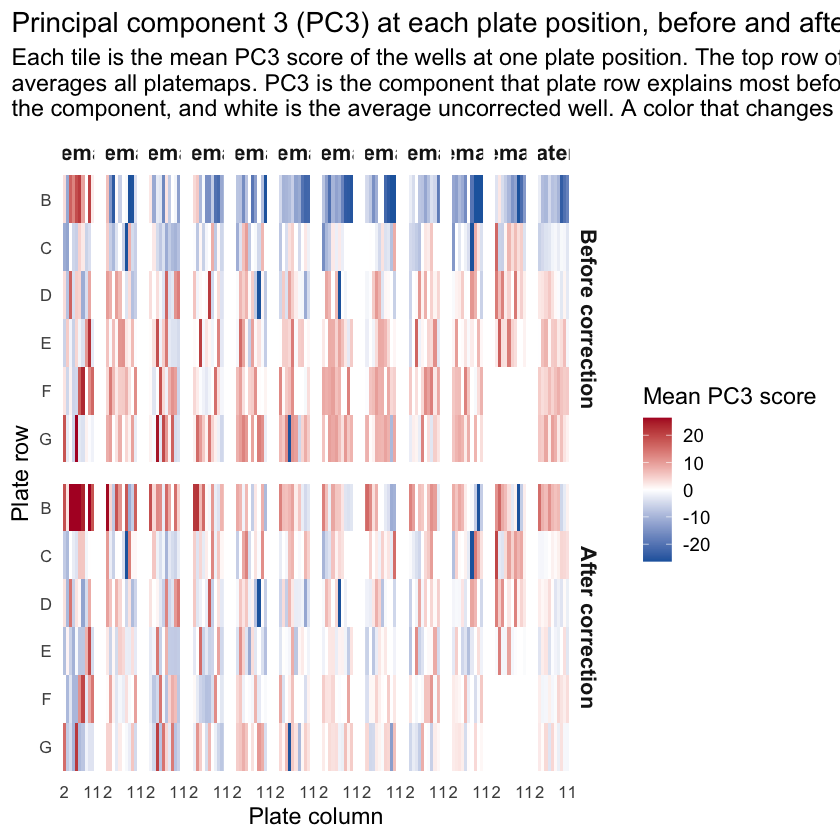

In [5]:
top_component <- variance_by_row |> slice_max(row_explains_before, n = 1) |> pull(component)
platemap_levels <- c(paste("Platemap", sort(unique(scores$platemap_number))), "All platemaps")

plate_grid <- bind_rows(
    scores |> mutate(platemap_label = paste("Platemap", platemap_number)),
    scores |> mutate(platemap_label = "All platemaps")
) |>
    group_by(version, platemap_label, well_row, well_col) |>
    summarize(score = mean(.data[[top_component]]), .groups = "drop") |>
    mutate(
        platemap_label = factor(platemap_label, levels = platemap_levels),
        well_row = factor(well_row, levels = rev(row_letters)),
        well_col = factor(well_col, levels = 2:11)
    )
limit <- quantile(abs(filter(plate_grid, version == "Before correction")$score), 0.98, na.rm = TRUE)

top_number <- as.integer(sub("PC", "", top_component))
figure <- (
    ggplot(plate_grid, aes(x = well_col, y = well_row, fill = score))
    + geom_tile()
    + facet_grid(rows = vars(version), cols = vars(platemap_label))
    + scale_fill_gradient2(
        low = "#2166AC", mid = "white", high = "#B2182B", limits = c(-limit, limit),
        oob = scales::squish, na.value = "gray85", name = paste("Mean", top_component, "score")
    )
    + scale_x_discrete(breaks = c(2, 11))
    + labs(
        title = sprintf(
            "Principal component %d (%s) at each plate position, before and after the correction",
            top_number, top_component
        ),
        subtitle = wrap_text(
            sprintf(
                paste(
                    "Each tile is the mean %s score of the wells at one plate position. The top row of panels is before the",
                    "correction and the bottom row is after it, and the last column averages all platemaps.",
                    "%s is the component that plate row explains most before the correction (%.0f%%, against %.0f%% after).",
                    "Positive and negative scores are the two ends of the component, and white is the average uncorrected well.",
                    "A color that changes from row to row (a horizontal stripe) is a plate-row effect."
                ),
                top_component, top_component,
                row_share(variance_by_row, top_component, "row_explains_before"),
                row_share(variance_by_row, top_component, "row_explains_after")
            ), 170
        ),
        x = "Plate column", y = "Plate row"
    )
    + theme_minimal(base_size = 14)
    + theme(
        panel.grid = element_blank(), axis.text = element_text(size = 10),
        strip.text = element_text(size = 13, face = "bold"),
        plot.title.position = "plot", plot.background = element_rect(fill = "white", color = NA)
    )
)
print(figure)
ggsave(
    file.path(figure_dir, "plate_layout_top_row_pc_before_after.png"), figure,
    dpi = 300, width = 18, height = 8, bg = "white"
)